In [47]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
    roc_auc_score,
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

DATA_DIR = Path("../data")
FIGURE_DIR = Path("../outputs/figures")
TABLE_DIR = Path("../outputs/tables")

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

customers = pd.read_parquet(
    DATA_DIR / "customer_retention_dataset.parquet"
)

print(customers.shape)
display(customers.head())

(5256, 18)


,customer_id,first_order_id,first_order_date,first_order_value,first_order_quantity,first_order_unique_products,first_order_product_lines,first_order_average_item_price,first_order_country,first_order_weekday,first_order_month,first_order_hour,first_order_is_weekend,second_order_date,days_to_second_order,available_followup_days,has_full_90d_followup,repeat_within_90d
0,12346,499763,2010-03-02 13:08:00,27.05,5,5,5,5.410000,United Kingdom,Tuesday,3,13,False,2010-06-28 13:53:00,118.031250,646.987500,True,0
1,12347,529924,2010-10-31 14:20:00,611.53,509,40,40,1.201434,Iceland,Sunday,10,14,True,2010-12-07 14:57:00,37.025694,403.937500,True,1
2,12348,524140,2010-09-27 14:59:00,221.16,372,19,19,0.594516,Finland,Monday,9,14,False,2010-12-16 19:09:00,80.173611,437.910417,True,1
3,12349,506394,2010-04-29 13:20:00,1068.52,473,46,46,2.259027,Italy,Thursday,4,13,False,2010-10-28 08:23:00,181.793750,588.979167,True,0
4,12350,543037,2011-02-02 16:01:00,294.40,196,16,16,1.502041,Norway,Wednesday,2,16,False,NaT,NaN,309.867361,True,0


In [48]:
assert customers["customer_id"].is_unique
assert customers["repeat_within_90d"].isin([0, 1]).all()
assert customers["available_followup_days"].ge(90).all()

In [49]:
numeric_features = [
    "first_order_value",
    "first_order_quantity",
    "first_order_unique_products",
    "first_order_product_lines",
    "first_order_average_item_price",
]

categorical_features = [
    "first_order_country",
    "first_order_weekday",
    "first_order_month",
    "first_order_hour",
]

feature_columns = (
    numeric_features
    + categorical_features
)

target_column = "repeat_within_90d"

In [50]:
train_end = pd.Timestamp("2010-12-01")
validation_end = pd.Timestamp("2011-05-01")

train_mask = (
    customers["first_order_date"] < train_end
)

validation_mask = (
    (customers["first_order_date"] >= train_end)
    & (customers["first_order_date"] < validation_end)
)

test_mask = (
    customers["first_order_date"] >= validation_end
)

In [51]:
X_train = customers.loc[
    train_mask, feature_columns
].copy()

y_train = customers.loc[
    train_mask, target_column
].copy()

X_validation = customers.loc[
    validation_mask, feature_columns
].copy()

y_validation = customers.loc[
    validation_mask, target_column
].copy()

X_test = customers.loc[
    test_mask, feature_columns
].copy()

y_test = customers.loc[
    test_mask, target_column
].copy()

In [52]:
assert (
    train_mask.astype(int)
    + validation_mask.astype(int)
    + test_mask.astype(int)
).eq(1).all()

assert len(X_train) + len(X_validation) + len(X_test) == len(customers)

assert customers.loc[
    train_mask, "first_order_date"
].max() < customers.loc[
    validation_mask, "first_order_date"
].min()

assert customers.loc[
    validation_mask, "first_order_date"
].max() < customers.loc[
    test_mask, "first_order_date"
].min()

In [53]:
split_summary = pd.DataFrame({
    "split": ["Train", "Validation", "Test"],
    "customers": [
        len(X_train),
        len(X_validation),
        len(X_test),
    ],
    "start_date": [
        customers.loc[train_mask, "first_order_date"].min(),
        customers.loc[validation_mask, "first_order_date"].min(),
        customers.loc[test_mask, "first_order_date"].min(),
    ],
    "end_date": [
        customers.loc[train_mask, "first_order_date"].max(),
        customers.loc[validation_mask, "first_order_date"].max(),
        customers.loc[test_mask, "first_order_date"].max(),
    ],
    "repeat_rate": [
        y_train.mean(),
        y_validation.mean(),
        y_test.mean(),
    ],
})

split_summary

,split,customers,start_date,end_date,repeat_rate
0,Train,4239,2009-12-01 07:45:00,2010-11-30 18:46:00,0.475348
1,Validation,558,2010-12-01 12:36:00,2011-04-28 16:40:00,0.353047
2,Test,459,2011-05-01 13:45:00,2011-09-09 14:14:00,0.507625


## Temporal validation strategy

Customers were divided chronologically according to their first-order date.
Earlier cohorts form the training set, subsequent cohorts form the validation
set, and the latest eligible cohorts form the final test set.

A random split would mix customers acquired at different points in time and
could overstate performance if retention patterns, seasonality, or customer
composition change. The test set therefore approximates deploying a model on
future customer cohorts.

The test set will remain untouched until all preprocessing and model choices
have been finalised using the training and validation sets.

In [54]:
training_repeat_rate = y_train.mean()

baseline_probabilities = {
    "Train": np.full(len(y_train), training_repeat_rate),
    "Validation": np.full(
        len(y_validation),
        training_repeat_rate
    ),
    "Test": np.full(
        len(y_test),
        training_repeat_rate
    ),
}

In [55]:
def evaluate_probabilities(y_true, probabilities, threshold=0.5):
    predictions = (
        np.asarray(probabilities) >= threshold
    ).astype(int)

    return {
        "customers": len(y_true),
        "positive_rate": y_true.mean(),
        "roc_auc": roc_auc_score(
            y_true,
            probabilities
        ),
        "pr_auc": average_precision_score(
            y_true,
            probabilities
        ),
        "log_loss": log_loss(
            y_true,
            probabilities
        ),
        "brier_score": brier_score_loss(
            y_true,
            probabilities
        ),
        "accuracy_at_0.5": accuracy_score(
            y_true,
            predictions
        ),
    }

In [56]:
baseline_results = pd.DataFrame([
    {
        "split": "Train",
        **evaluate_probabilities(
            y_train,
            baseline_probabilities["Train"]
        ),
    },
    {
        "split": "Validation",
        **evaluate_probabilities(
            y_validation,
            baseline_probabilities["Validation"]
        ),
    },
    {
        "split": "Test",
        **evaluate_probabilities(
            y_test,
            baseline_probabilities["Test"]
        ),
    },
])

baseline_results

,split,customers,positive_rate,roc_auc,pr_auc,log_loss,brier_score,accuracy_at_0.5
0,Train,4239,0.475348,0.5,0.475348,0.691931,0.249392,0.524652
1,Validation,558,0.353047,0.5,0.353047,0.679862,0.243362,0.646953
2,Test,459,0.507625,0.5,0.507625,0.695117,0.250984,0.492375


In [57]:
split_summary.to_csv(
    TABLE_DIR / "temporal_split_summary.csv",
    index=False
)

baseline_results.to_csv(
    TABLE_DIR / "baseline_results.csv",
    index=False
)

## Baseline interpretation

The repeat rate changed substantially across time: 47.53% in training,
35.30% in validation, and 50.76% in testing. This indicates temporal
variation in either customer composition or repeat-purchasing behaviour.

The constant-probability baseline had no ranking ability, with ROC-AUC
equal to 0.5. Its validation accuracy of 64.70% arose because the training
repeat rate was below the 0.5 classification threshold, causing every
customer to be classified as a non-repeat customer. Accuracy is therefore
not an appropriate primary metric for this problem.

The test set will not be used again until model and preprocessing choices
have been finalised using the training and validation sets.

## Logistic regression


In [58]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    OneHotEncoder,
    StandardScaler,
)

In [59]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "log_transform",
        FunctionTransformer(
            np.log1p,
            feature_names_out="one-to-one"
        )
    ),
    (
        "scaler",
        StandardScaler()
    ),
])

In [60]:
categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "one_hot",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    ),
])

In [61]:
preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    ),
])

In [62]:
logistic_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        LogisticRegression(
            C=1.0,
            l1_ratio=0,
            solver="liblinear",
            max_iter=2000,
            random_state=42,
        )
    ),
])

In [63]:
logistic_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

In [64]:
logistic_train_probabilities = (
    logistic_pipeline.predict_proba(X_train)[:, 1]
)

logistic_validation_probabilities = (
    logistic_pipeline.predict_proba(X_validation)[:, 1]
)

In [65]:
logistic_results = pd.DataFrame([
    {
        "model": "Logistic regression",
        "split": "Train",
        **evaluate_probabilities(
            y_train,
            logistic_train_probabilities
        ),
    },
    {
        "model": "Logistic regression",
        "split": "Validation",
        **evaluate_probabilities(
            y_validation,
            logistic_validation_probabilities
        ),
    },
])

logistic_results

,model,split,customers,positive_rate,roc_auc,pr_auc,log_loss,brier_score,accuracy_at_0.5
0,Logistic regression,Train,4239,0.475348,0.649891,0.616764,0.656759,0.232306,0.611937
1,Logistic regression,Validation,558,0.353047,0.529522,0.363589,0.693786,0.250199,0.550179


In [66]:
baseline_comparison = (
    baseline_results[
        baseline_results["split"].isin(
            ["Train", "Validation"]
        )
    ]
    .copy()
)

baseline_comparison.insert(
    0,
    "model",
    "Constant probability"
)

model_comparison = pd.concat(
    [
        baseline_comparison,
        logistic_results,
    ],
    ignore_index=True
)

model_comparison[
    [
        "model",
        "split",
        "roc_auc",
        "pr_auc",
        "log_loss",
        "brier_score",
        "accuracy_at_0.5",
    ]
]

,model,split,roc_auc,pr_auc,log_loss,brier_score,accuracy_at_0.5
0,Constant probability,Train,0.500000,0.475348,0.691931,0.249392,0.524652
1,Constant probability,Validation,0.500000,0.353047,0.679862,0.243362,0.646953
2,Logistic regression,Train,0.649891,0.616764,0.656759,0.232306,0.611937
3,Logistic regression,Validation,0.529522,0.363589,0.693786,0.250199,0.550179


First-order characteristics contain predictive information in the training period, but the logistic regression transfers poorly to later cohorts. This suggests temporal drift and possible changes in customer composition or purchasing behaviour.

## Prediction calibration


In [67]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

print("Mean predicted probability:")
print(
    f"Train: "
    f"{logistic_train_probabilities.mean():.4f}"
)
print(
    f"Validation: "
    f"{logistic_validation_probabilities.mean():.4f}"
)

print("\nActual repeat rate:")
print(f"Train:      {y_train.mean():.4f}")
print(f"Validation: {y_validation.mean():.4f}")

Mean predicted probability:
Train: 0.4754
Validation: 0.4713

Actual repeat rate:
Train:      0.4753
Validation: 0.3530


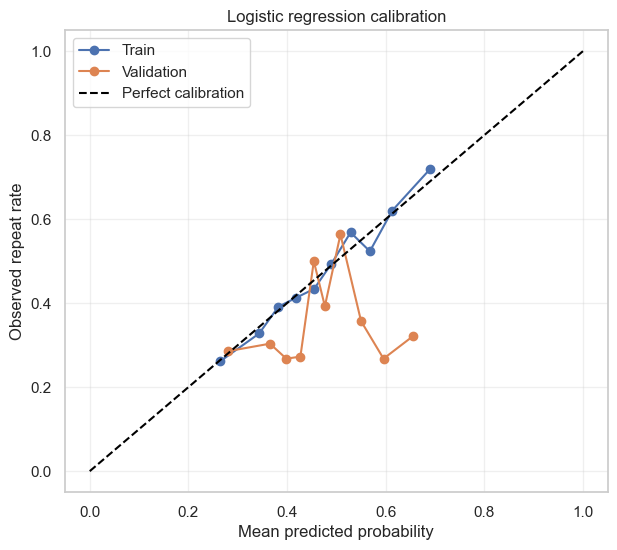

In [68]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

train_fraction_positive, train_mean_predicted = calibration_curve(
    y_train,
    logistic_train_probabilities,
    n_bins=10,
    strategy="quantile"
)

validation_fraction_positive, validation_mean_predicted = calibration_curve(
    y_validation,
    logistic_validation_probabilities,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 6))

plt.plot(
    train_mean_predicted,
    train_fraction_positive,
    marker="o",
    label="Train"
)

plt.plot(
    validation_mean_predicted,
    validation_fraction_positive,
    marker="o",
    label="Validation"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed repeat rate")
plt.title("Logistic regression calibration")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Logistic regression calibration

The logistic regression is reasonably calibrated on the training
cohorts, but its calibration deteriorates on the later validation
cohorts. In particular, the higher predicted-probability groups have
substantially lower observed repeat rates than predicted.

This is consistent with temporal drift: the repeat rate fell from
47.5% in training to 35.3% in validation. Therefore, relationships
learned from the earlier cohorts do not transfer reliably to the
validation period. The model provides only weak out-of-time ranking
ability and overestimates repeat probabilities for several validation
groups.

## Decisiom Tree


In [69]:
from sklearn.base import clone
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "model",
            DecisionTreeClassifier(
                max_depth=3,
                min_samples_leaf=50,
                class_weight=None,
                random_state=42
            )
        )
    ]
)

tree_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

In [70]:
tree_train_probabilities = tree_pipeline.predict_proba(
    X_train
)[:, 1]

tree_validation_probabilities = tree_pipeline.predict_proba(
    X_validation
)[:, 1]

In [71]:
tree_train_metrics = evaluate_probabilities(
    y_train,
    tree_train_probabilities
)

tree_validation_metrics = evaluate_probabilities(
    y_validation,
    tree_validation_probabilities
)

tree_results = pd.DataFrame(
    [
        {
            "model": "Shallow decision tree",
            "split": "Train",
            **tree_train_metrics
        },
        {
            "model": "Shallow decision tree",
            "split": "Validation",
            **tree_validation_metrics
        }
    ]
)

display(tree_results)

,model,split,customers,positive_rate,roc_auc,pr_auc,log_loss,brier_score,accuracy_at_0.5
0,Shallow decision tree,Train,4239,0.475348,0.621334,0.577008,0.665662,0.236652,0.592357
1,Shallow decision tree,Validation,558,0.353047,0.530162,0.379844,0.679795,0.243185,0.560932


In [72]:
baseline_results["model"] = "Constant probability"

model_comparison = pd.concat(
    [
        baseline_results.loc[
            baseline_results["split"].isin(
                ["Train", "Validation"]
            )
        ],
        logistic_results,
        tree_results
    ],
    ignore_index=True
)

display(
    model_comparison[
        [
            "model",
            "split",
            "roc_auc",
            "pr_auc",
            "log_loss",
            "brier_score",
            "accuracy_at_0.5"
        ]
    ]
)

,model,split,roc_auc,pr_auc,log_loss,brier_score,accuracy_at_0.5
0,Constant probability,Train,0.500000,0.475348,0.691931,0.249392,0.524652
1,Constant probability,Validation,0.500000,0.353047,0.679862,0.243362,0.646953
2,Logistic regression,Train,0.649891,0.616764,0.656759,0.232306,0.611937
3,Logistic regression,Validation,0.529522,0.363589,0.693786,0.250199,0.550179
4,Shallow decision tree,Train,0.621334,0.577008,0.665662,0.236652,0.592357
5,Shallow decision tree,Validation,0.530162,0.379844,0.679795,0.243185,0.560932


### Shallow decision-tree results

The shallow decision tree provided the strongest validation results so
far. It achieved a validation PR-AUC of 0.380, compared with 0.364 for
logistic regression and 0.353 for the constant baseline. It also
slightly improved log loss and Brier score relative to the baseline.

However, its validation ROC-AUC was only 0.530. Therefore, first-order
features provide limited out-of-time discrimination. The results also
indicate temporal instability, since all fitted models performed much
better on the training cohorts than on the later validation cohorts.

## Boosted-tree


In [73]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

boosted_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

boosted_categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "one_hot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

boosted_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            boosted_numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            boosted_categorical_pipeline,
            categorical_features
        )
    ]
)

In [74]:
boosted_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            boosted_preprocessor
        ),
        (
            "model",
            HistGradientBoostingClassifier(
                learning_rate=0.05,
                max_iter=150,
                max_leaf_nodes=15,
                min_samples_leaf=50,
                l2_regularization=1.0,
                random_state=42
            )
        )
    ]
)

boosted_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

In [75]:
boosted_train_probabilities = (
    boosted_pipeline.predict_proba(X_train)[:, 1]
)

boosted_validation_probabilities = (
    boosted_pipeline.predict_proba(
        X_validation
    )[:, 1]
)

In [76]:
boosted_train_metrics = evaluate_probabilities(
    y_train,
    boosted_train_probabilities
)

boosted_validation_metrics = evaluate_probabilities(
    y_validation,
    boosted_validation_probabilities
)

boosted_results = pd.DataFrame(
    [
        {
            "model": "Boosted trees",
            "split": "Train",
            **boosted_train_metrics
        },
        {
            "model": "Boosted trees",
            "split": "Validation",
            **boosted_validation_metrics
        }
    ]
)

display(boosted_results)

,model,split,customers,positive_rate,roc_auc,pr_auc,log_loss,brier_score,accuracy_at_0.5
0,Boosted trees,Train,4239,0.475348,0.765893,0.743616,0.597277,0.204750,0.696862
1,Boosted trees,Validation,558,0.353047,0.566770,0.393414,0.676797,0.242128,0.555556


In [77]:
model_comparison = pd.concat(
    [
        baseline_results.loc[
            baseline_results["split"].isin(
                ["Train", "Validation"]
            )
        ],
        logistic_results,
        tree_results,
        boosted_results
    ],
    ignore_index=True
)

display(
    model_comparison[
        [
            "model",
            "split",
            "roc_auc",
            "pr_auc",
            "log_loss",
            "brier_score",
            "accuracy_at_0.5"
        ]
    ]
)

,model,split,roc_auc,pr_auc,log_loss,brier_score,accuracy_at_0.5
0,Constant probability,Train,0.500000,0.475348,0.691931,0.249392,0.524652
1,Constant probability,Validation,0.500000,0.353047,0.679862,0.243362,0.646953
2,Logistic regression,Train,0.649891,0.616764,0.656759,0.232306,0.611937
3,Logistic regression,Validation,0.529522,0.363589,0.693786,0.250199,0.550179
4,Shallow decision tree,Train,0.621334,0.577008,0.665662,0.236652,0.592357
5,Shallow decision tree,Validation,0.530162,0.379844,0.679795,0.243185,0.560932
6,Boosted trees,Train,0.765893,0.743616,0.597277,0.204750,0.696862
7,Boosted trees,Validation,0.566770,0.393414,0.676797,0.242128,0.555556


### Boosted-tree results

The boosted-tree model achieved the strongest validation performance.
Its validation ROC-AUC was 0.567 and its PR-AUC was 0.393, compared
with 0.530 and 0.380 for the shallow decision tree. It also produced
the lowest validation log loss and Brier score.

However, performance fell substantially from training to validation:
ROC-AUC decreased from 0.766 to 0.567. This indicates that the model
overfits the earlier cohorts and that relationships between first-order
features and repeat purchasing are temporally unstable.

Boosting therefore provides a modest improvement, but first-order
transaction features alone do not support highly accurate out-of-time
prediction.

In [78]:
from sklearn.base import clone

boosted_configurations = [
    {
        "name": "Very conservative",
        "max_iter": 100,
        "max_leaf_nodes": 7,
        "min_samples_leaf": 100,
        "l2_regularization": 2.0
    },
    {
        "name": "Conservative",
        "max_iter": 100,
        "max_leaf_nodes": 15,
        "min_samples_leaf": 100,
        "l2_regularization": 2.0
    },
    {
        "name": "Current model",
        "max_iter": 150,
        "max_leaf_nodes": 15,
        "min_samples_leaf": 50,
        "l2_regularization": 1.0
    }
]

tuning_rows = []
boosted_candidates = {}

for configuration in boosted_configurations:
    candidate_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                clone(boosted_preprocessor)
            ),
            (
                "model",
                HistGradientBoostingClassifier(
                    learning_rate=0.05,
                    max_iter=configuration["max_iter"],
                    max_leaf_nodes=configuration[
                        "max_leaf_nodes"
                    ],
                    min_samples_leaf=configuration[
                        "min_samples_leaf"
                    ],
                    l2_regularization=configuration[
                        "l2_regularization"
                    ],
                    random_state=42
                )
            )
        ]
    )

    candidate_pipeline.fit(X_train, y_train)

    train_probabilities = (
        candidate_pipeline.predict_proba(X_train)[:, 1]
    )

    validation_probabilities = (
        candidate_pipeline.predict_proba(
            X_validation
        )[:, 1]
    )

    train_metrics = evaluate_probabilities(
        y_train,
        train_probabilities
    )

    validation_metrics = evaluate_probabilities(
        y_validation,
        validation_probabilities
    )

    tuning_rows.append(
        {
            "configuration": configuration["name"],
            "split": "Train",
            **train_metrics
        }
    )

    tuning_rows.append(
        {
            "configuration": configuration["name"],
            "split": "Validation",
            **validation_metrics
        }
    )

    boosted_candidates[
        configuration["name"]
    ] = candidate_pipeline

boosted_tuning_results = pd.DataFrame(tuning_rows)

display(
    boosted_tuning_results[
        [
            "configuration",
            "split",
            "roc_auc",
            "pr_auc",
            "log_loss",
            "brier_score"
        ]
    ]
)

,configuration,split,roc_auc,pr_auc,log_loss,brier_score
0,Very conservative,Train,0.677363,0.650033,0.644714,0.226738
1,Very conservative,Validation,0.562847,0.382386,0.675935,0.241485
2,Conservative,Train,0.728475,0.699943,0.619843,0.215029
3,Conservative,Validation,0.561089,0.385696,0.677371,0.242265
4,Current model,Train,0.765893,0.743616,0.597277,0.204750
5,Current model,Validation,0.566770,0.393414,0.676797,0.242128


In [79]:
selected_boosted_model = boosted_candidates[
    "Current model"
]

selected_validation_probabilities = (
    selected_boosted_model.predict_proba(
        X_validation
    )[:, 1]
)

### Boosted-tree model selection

Three deliberately limited configurations were compared to assess the
trade-off between model flexibility and overfitting.

The current configuration was selected because it achieved the highest
validation ROC-AUC and PR-AUC. The very conservative configuration
produced marginally better log loss and Brier score, but its ranking
performance was weaker.

Because the intended use case is prioritising customers under limited
marketing capacity, validation ranking performance was given greater
weight. No further hyperparameter search was conducted to reduce the
risk of adapting excessively to the validation period.

## Evaluate the top 10% of customers


In [80]:
def evaluate_at_capacity(
    y_true,
    probabilities,
    capacity=0.10
):
    y_array = np.asarray(y_true)
    probability_array = np.asarray(probabilities)

    selected_count = int(
        np.ceil(len(y_array) * capacity)
    )

    selected_indices = np.argsort(
        probability_array
    )[::-1][:selected_count]

    selected_actual = y_array[selected_indices]

    selected_repeat_rate = selected_actual.mean()
    overall_repeat_rate = y_array.mean()

    lift = (
        selected_repeat_rate
        / overall_repeat_rate
    )

    recall_at_capacity = (
        selected_actual.sum()
        / y_array.sum()
    )

    return {
        "capacity": capacity,
        "selected_customers": selected_count,
        "selected_repeat_rate": selected_repeat_rate,
        "overall_repeat_rate": overall_repeat_rate,
        "lift": lift,
        "recall_at_capacity": recall_at_capacity
    }

In [81]:
capacity_rows = []

validation_model_probabilities = {
    "Logistic regression":
        logistic_validation_probabilities,
    "Shallow decision tree":
        tree_validation_probabilities,
    "Boosted trees":
        selected_validation_probabilities
}

for model_name, probabilities in (
    validation_model_probabilities.items()
):
    capacity_metrics = evaluate_at_capacity(
        y_validation,
        probabilities,
        capacity=0.10
    )

    capacity_rows.append(
        {
            "model": model_name,
            **capacity_metrics
        }
    )

capacity_results = pd.DataFrame(capacity_rows)

display(capacity_results)

,model,capacity,selected_customers,selected_repeat_rate,overall_repeat_rate,lift,recall_at_capacity
0,Logistic regression,0.1,56,0.321429,0.353047,0.910442,0.091371
1,Shallow decision tree,0.1,56,0.321429,0.353047,0.910442,0.091371
2,Boosted trees,0.1,56,0.410714,0.353047,1.163343,0.116751


### Performance at 10% targeting capacity

At a 10% targeting capacity, the boosted-tree model selected 56
validation customers with an observed repeat rate of 41.1%, compared
with 35.3% across all validation customers. This corresponds to a lift
of 1.16: the selected group had a repeat rate approximately 16% higher
than the validation average.

The selected group contained 11.7% of all validation repeat customers.
In contrast, the logistic regression and shallow decision tree produced
lift below one at this capacity.

This result demonstrates modest predictive concentration rather than
causal impact. It does not show that contacting these customers would
increase repeat purchasing, since many may have repeated without any
intervention.

In [82]:
from sklearn.inspection import permutation_importance

permutation_results = permutation_importance(
    selected_boosted_model,
    X_validation,
    y_validation,
    scoring="average_precision",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

feature_importance = pd.DataFrame(
    {
        "feature": X_validation.columns,
        "importance_mean":
            permutation_results.importances_mean,
        "importance_std":
            permutation_results.importances_std
    }
).sort_values(
    "importance_mean",
    ascending=False
)

display(feature_importance)

,feature,importance_mean,importance_std
0,first_order_value,0.048336,0.008602
1,first_order_quantity,0.015632,0.008248
2,first_order_unique_products,0.013565,0.007677
3,first_order_product_lines,0.003842,0.004226
8,first_order_hour,0.002112,0.006526
6,first_order_weekday,0.000925,0.003408
5,first_order_country,0.000052,0.003766
4,first_order_average_item_price,-0.001566,0.008590
7,first_order_month,-0.034764,0.016623


### Permutation importance

First-order value was the strongest contributor to out-of-time ranking
performance. Quantity and product diversity provided smaller positive
contributions, while country, weekday and order hour contributed little.

First-order month had negative validation permutation importance. This
suggests that the boosted model learned seasonal relationships from the
training cohorts that did not transfer to the later validation period.
This is consistent with the temporal variation observed during
exploratory analysis.

The basket-related features are correlated, so their individual
permutation importances should not be interpreted as independent or
causal effects.

In [83]:
reduced_categorical_features = [
    feature
    for feature in categorical_features
    if feature != "first_order_month"
]

reduced_boosted_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            clone(boosted_numeric_pipeline),
            numeric_features
        ),
        (
            "categorical",
            clone(boosted_categorical_pipeline),
            reduced_categorical_features
        )
    ]
)

boosted_without_month = Pipeline(
    steps=[
        (
            "preprocessor",
            reduced_boosted_preprocessor
        ),
        (
            "model",
            HistGradientBoostingClassifier(
                learning_rate=0.05,
                max_iter=150,
                max_leaf_nodes=15,
                min_samples_leaf=50,
                l2_regularization=1.0,
                random_state=42
            )
        )
    ]
)

boosted_without_month.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

In [84]:
no_month_train_probabilities = (
    boosted_without_month.predict_proba(
        X_train
    )[:, 1]
)

no_month_validation_probabilities = (
    boosted_without_month.predict_proba(
        X_validation
    )[:, 1]
)

no_month_results = pd.DataFrame(
    [
        {
            "model": "Boosted trees without month",
            "split": "Train",
            **evaluate_probabilities(
                y_train,
                no_month_train_probabilities
            )
        },
        {
            "model": "Boosted trees without month",
            "split": "Validation",
            **evaluate_probabilities(
                y_validation,
                no_month_validation_probabilities
            )
        }
    ]
)

display(no_month_results)

,model,split,customers,positive_rate,roc_auc,pr_auc,log_loss,brier_score,accuracy_at_0.5
0,Boosted trees without month,Train,4239,0.475348,0.751422,0.732353,0.612474,0.211568,0.677990
1,Boosted trees without month,Validation,558,0.353047,0.601361,0.463486,0.660179,0.234247,0.589606


In [85]:
display(
    pd.DataFrame(
        [
            {
                "model": "Boosted trees without month",
                **evaluate_at_capacity(
                    y_validation,
                    no_month_validation_probabilities,
                    capacity=0.10
                )
            }
        ]
    )
)

,model,capacity,selected_customers,selected_repeat_rate,overall_repeat_rate,lift,recall_at_capacity
0,Boosted trees without month,0.1,56,0.553571,0.353047,1.567984,0.15736


### Robustness to removing calendar month

Removing first-order month substantially improved all validation
metrics. Validation ROC-AUC increased from 0.567 to 0.601, while PR-AUC
increased from 0.393 to 0.463. Log loss and Brier score also improved.

At a 10% targeting capacity, the selected group's repeat rate increased
to 55.4%, compared with an overall validation repeat rate of 35.3%.
This represents a lift of 1.57.

The result indicates that calendar-month patterns learned from earlier
cohorts were unstable and harmful out of time. The boosted-tree model
without month was therefore selected as the final specification.

In [86]:
X_development = pd.concat(
    [X_train, X_validation],
    axis=0
)

y_development = pd.concat(
    [y_train, y_validation],
    axis=0
)

final_model = clone(boosted_without_month)

final_model.fit(
    X_development,
    y_development
)

final_test_probabilities = (
    final_model.predict_proba(X_test)[:, 1]
)

In [87]:
development_repeat_rate = y_development.mean()

final_baseline_test_probabilities = np.full(
    len(y_test),
    development_repeat_rate
)

In [88]:
final_test_results = pd.DataFrame(
    [
        {
            "model": "Constant probability",
            "split": "Test",
            **evaluate_probabilities(
                y_test,
                final_baseline_test_probabilities
            )
        },
        {
            "model": "Boosted trees without month",
            "split": "Test",
            **evaluate_probabilities(
                y_test,
                final_test_probabilities
            )
        }
    ]
)

display(final_test_results)

,model,split,customers,positive_rate,roc_auc,pr_auc,log_loss,brier_score,accuracy_at_0.5
0,Constant probability,Test,459,0.507625,0.500000,0.507625,0.697368,0.252104,0.492375
1,Boosted trees without month,Test,459,0.507625,0.561586,0.569427,0.701471,0.253362,0.551198


In [89]:
final_test_capacity = pd.DataFrame(
    [
        {
            "model": "Boosted trees without month",
            "split": "Test",
            **evaluate_at_capacity(
                y_test,
                final_test_probabilities,
                capacity=0.10
            )
        }
    ]
)

display(final_test_capacity)

,model,split,capacity,selected_customers,selected_repeat_rate,overall_repeat_rate,lift,recall_at_capacity
0,Boosted trees without month,Test,0.1,46,0.586957,0.507625,1.156279,0.11588


### Final out-of-time test performance

After model selection, the boosted-tree model without calendar month
was refitted using the combined training and validation periods and
evaluated once on the held-out test cohort.

The final model achieved a test ROC-AUC of 0.562 and PR-AUC of 0.569,
compared with baseline values of 0.500 and 0.508. This demonstrates
modest out-of-time ranking ability.

At a 10% targeting capacity, the model selected 46 customers with an
observed repeat rate of 58.7%, compared with 50.8% across the test
cohort. This corresponds to a lift of 1.16, and the selected group
captured 11.6% of all test-period repeat customers.

However, test log loss and Brier score were slightly worse than the
constant-probability baseline. Therefore, the model is more useful for
coarse customer ranking than for producing reliable individual repeat
probabilities.

The weaker test lift relative to validation also reinforces the
presence of temporal instability. No further model or feature changes
were made after examining the test results.

In [90]:
bootstrap_rng = np.random.default_rng(42)

bootstrap_rows = []
bootstrap_iterations = 2000

y_test_array = np.asarray(y_test)
test_probability_array = np.asarray(
    final_test_probabilities
)

for iteration in range(bootstrap_iterations):
    bootstrap_indices = bootstrap_rng.choice(
        len(y_test_array),
        size=len(y_test_array),
        replace=True
    )

    bootstrap_y = y_test_array[
        bootstrap_indices
    ]

    bootstrap_probabilities = (
        test_probability_array[
            bootstrap_indices
        ]
    )

    # Safety check in case a resample contains one class
    if np.unique(bootstrap_y).size < 2:
        continue

    capacity_metrics = evaluate_at_capacity(
        bootstrap_y,
        bootstrap_probabilities,
        capacity=0.10
    )

    bootstrap_rows.append(
        {
            "roc_auc": roc_auc_score(
                bootstrap_y,
                bootstrap_probabilities
            ),
            "pr_auc": average_precision_score(
                bootstrap_y,
                bootstrap_probabilities
            ),
            "log_loss": log_loss(
                bootstrap_y,
                bootstrap_probabilities
            ),
            "brier_score": brier_score_loss(
                bootstrap_y,
                bootstrap_probabilities
            ),
            "top_10_lift": capacity_metrics["lift"],
            "top_10_repeat_rate":
                capacity_metrics[
                    "selected_repeat_rate"
                ]
        }
    )

bootstrap_results = pd.DataFrame(
    bootstrap_rows
)

In [91]:
point_estimates = {
    "roc_auc": roc_auc_score(
        y_test,
        final_test_probabilities
    ),
    "pr_auc": average_precision_score(
        y_test,
        final_test_probabilities
    ),
    "log_loss": log_loss(
        y_test,
        final_test_probabilities
    ),
    "brier_score": brier_score_loss(
        y_test,
        final_test_probabilities
    ),
    "top_10_lift": final_test_capacity.loc[
        0, "lift"
    ],
    "top_10_repeat_rate":
        final_test_capacity.loc[
            0, "selected_repeat_rate"
        ]
}

bootstrap_summary_rows = []

for metric, point_estimate in point_estimates.items():
    bootstrap_summary_rows.append(
        {
            "metric": metric,
            "estimate": point_estimate,
            "ci_low": bootstrap_results[
                metric
            ].quantile(0.025),
            "ci_high": bootstrap_results[
                metric
            ].quantile(0.975)
        }
    )

bootstrap_summary = pd.DataFrame(
    bootstrap_summary_rows
)

display(bootstrap_summary)

,metric,estimate,ci_low,ci_high
0,roc_auc,0.561586,0.510932,0.613913
1,pr_auc,0.569427,0.509788,0.638298
2,log_loss,0.701471,0.677373,0.724828
3,brier_score,0.253362,0.242082,0.264291
4,top_10_lift,1.156279,0.899670,1.473619
5,top_10_repeat_rate,0.586957,0.456522,0.739130


### Uncertainty in final test performance

Bootstrap confidence intervals were calculated using 2,000 resamples of
the test cohort.

The final model achieved a test ROC-AUC of 0.562, with a 95% bootstrap
interval of [0.511, 0.614]. The interval narrowly excluded 0.5,
providing evidence of modest better-than-random ranking ability.

Test PR-AUC was 0.569, with an interval of [0.510, 0.638]. Its lower
bound was close to the test repeat rate of 0.508, indicating that the
incremental ranking value is limited.

Top-10% lift was estimated at 1.16, but its interval of [0.90, 1.47]
included one. Therefore, the test sample does not provide strong
evidence that the top-ranked group consistently has an above-average
repeat rate. This estimate is imprecise because only 46 test customers
were selected at the 10% capacity threshold.

Overall, the model demonstrates modest ranking value, but the evidence
is not sufficiently strong to support confident automated targeting.

## Recommended retention experiment

### Objective

Estimate whether a post-purchase intervention increases the probability
of a second valid purchase within 90 days.

### Experimental design

- Unit of randomisation: customer.
- Eligibility: customers completing their first valid order.
- Control: existing post-purchase experience.
- Treatment: a predefined retention intervention, such as a personalised
  product reminder or time-limited incentive.
- Primary metric: valid repeat purchase within 90 days.
- Guardrail metrics: 90-day net revenue, gross margin, cancellation and
  return rates, and unsubscribe rate.
- Analysis: intention-to-treat difference in repeat rates, accompanied
  by a confidence interval.

Customers should first be divided into broad predicted-repeat-probability
groups, such as low, medium and high. Treatment and control assignment
should then be randomised within each group. This ensures balance and
allows investigation of whether treatment effects vary by predicted
baseline retention.

The predictive model should not be used to assume that low-probability
or high-probability customers will have the largest treatment response.
Only the randomised experiment can estimate incremental impact.

### Validity checks

Before interpreting results, check:

- sample-ratio mismatch;
- balance in pre-treatment customer characteristics;
- correct exposure and event logging;
- sufficient 90-day follow-up;
- treatment spillovers or repeated customer identities;
- guardrail deterioration;
- multiple-testing risk for segment analyses.

### Decision rule

An intervention should be recommended only if the estimated improvement
is practically meaningful, its confidence interval supports a positive
effect, and the additional revenue or margin exceeds the intervention
cost without unacceptable guardrail deterioration.